In [27]:
# Cell 1
import pandas as pd

df = pd.read_csv("EURUSD240.csv", sep='\t', lineterminator='\n', names=["Date", "Open", "High", "Low", "Close", "Volume"], header=None)
print(df.head())
print(df.shape)

               Date     Open     High      Low    Close  Volume
0  2008-02-15 00:00  1.46326  1.46381  1.46292  1.46321   12771
1  2008-02-15 04:00  1.46346  1.46646  1.46283  1.46441  151025
2  2008-02-15 08:00  1.46455  1.46974  1.46394  1.46757  240571
3  2008-02-15 12:00  1.46753  1.47084  1.46516  1.46856  175351
4  2008-02-15 16:00  1.46856  1.46953  1.46533  1.46767  151899
(25848, 6)


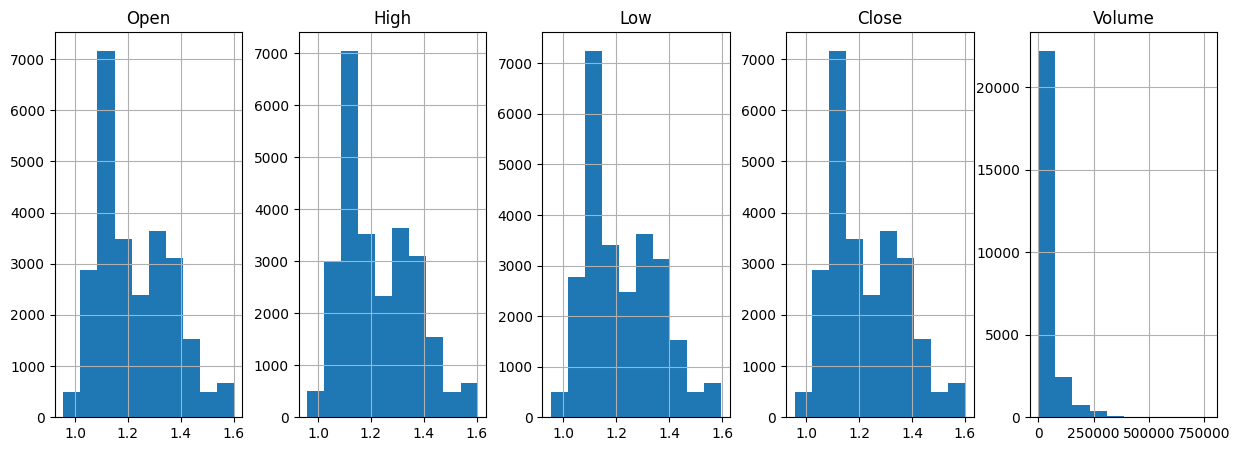

In [28]:
# Cell 2
import numpy as np
import matplotlib.pyplot as plt


df.hist(layout=(1,5), figsize=(15,5))

plt.show()

In [29]:
# Cell 3
import numpy as np
# from mlxtend.preprocessing import standardize

datanp = df[["Open", "High", "Low", "Close", "Volume"]].to_numpy()

def get_gaussian_parameters(data, axis=0):
    if axis == 0:
        c = data.shape[1]
    else:
        c = data.shape[0]
    parameters = np.zeros(2*c)

    for i in range(c):
        if axis == 0:
            column_data = data[:, i]
        else:
            column_data = data[i, :]
        mean = np.mean(column_data)
        std_dev = np.std(column_data)

        parameters[2*i] = mean
        parameters[2*i + 1] = std_dev

    return np.round(parameters, 5)

dlist = []
d4plotting = []

window = 8
overlap = 2
for i in range(0, len(datanp), window - overlap):
    temp = datanp[i:i + window, ].copy()
    if len(temp) != window:
        continue
    d4plotting.append(temp.copy())
    print("i:", i)
    for j in range(1,len(temp)):
        print("first:", temp[j], temp[j-1])
        temp[j] = temp[j] - temp[j - 1]
        print("second:", temp[j], temp[j-1])
    row_params = get_gaussian_parameters(temp, axis=1)
    col_params = get_gaussian_parameters(temp, axis=0)

    # print(standardize(temp))
    dlist.append(np.concatenate((np.round(np.reshape(temp, (-1, window * 5)), 5)[0], row_params,col_params), axis=None))



dlist = np.array(dlist, dtype=object)

dlist_copy = dlist.copy()
print(dlist.shape)
print(dlist[0:30, ])

d4plotting = np.array(d4plotting)
d4plotting = d4plotting.reshape(-1, d4plotting.shape[1]* d4plotting.shape[2])

Streaming output truncated to the last 5000 lines.
second: [ 1.04307e+00  1.03211e+00  1.03807e+00  1.03061e+00 -1.10010e+04] [-5.21000e-03  7.31000e-03 -2.87000e-03  7.51000e-03  1.10291e+05]
first: [1.03808e+00 1.03933e+00 1.03507e+00 1.03824e+00 1.38553e+05] [ 1.04307e+00  1.03211e+00  1.03807e+00  1.03061e+00 -1.10010e+04]
second: [-4.99000e-03  7.22000e-03 -3.00000e-03  7.63000e-03  1.49554e+05] [ 1.04307e+00  1.03211e+00  1.03807e+00  1.03061e+00 -1.10010e+04]
i: 23850
first: [1.03808e+00 1.03933e+00 1.03507e+00 1.03824e+00 1.38553e+05] [1.03786e+00 1.03942e+00 1.03520e+00 1.03812e+00 9.92900e+04]
second: [ 2.2000e-04 -9.0000e-05 -1.3000e-04  1.2000e-04  3.9263e+04] [1.03786e+00 1.03942e+00 1.03520e+00 1.03812e+00 9.92900e+04]
first: [1.03823e+00 1.03842e+00 1.03245e+00 1.03561e+00 1.80617e+05] [ 2.2000e-04 -9.0000e-05 -1.3000e-04  1.2000e-04  3.9263e+04]
second: [1.03801e+00 1.03851e+00 1.03258e+00 1.03549e+00 1.41354e+05] [ 2.2000e-04 -9.0000e-05 -1.3000e-04  1.2000e-04  3.9263

         1        2        3        4        5        6        7        8  \
0  1.46326  1.46381  1.46292  1.46321  12771.0   0.0002  0.00265 -0.00009   
1   1.4679  1.46806  1.46626  1.46708  53412.0 -0.00078  0.00001 -0.00031   
2  1.46543  1.46614  1.46374  1.46478  54116.0 -0.00075  0.00036  0.00004   
3  1.47309  1.47349   1.4719  1.47274  54282.0 -0.00004 -0.00019 -0.00103   
4  1.47132  1.47249  1.47005  1.47207  54538.0  0.00068 -0.00006  0.00056   

         9        10  ...       57       58       59       60       61  \
0   0.0012  138254.0  ...  0.73319  0.73153  0.73428  0.73113  0.73261   
1   0.0003   41341.0  ...  0.73298   0.7329  0.73356  0.73458  0.73178   
2  0.00097   39603.0  ...  0.73565  0.73091  0.73627  0.73537  0.73465   
3 -0.00015   40469.0  ...  0.73494  0.73816  0.73636  0.73409  0.73395   
4      0.0   39943.0  ...  0.73798   0.7334   0.7392  0.73653  0.73707   

        62       63       64         65           66  
0  0.73105  0.73355  0.73135  57883.1

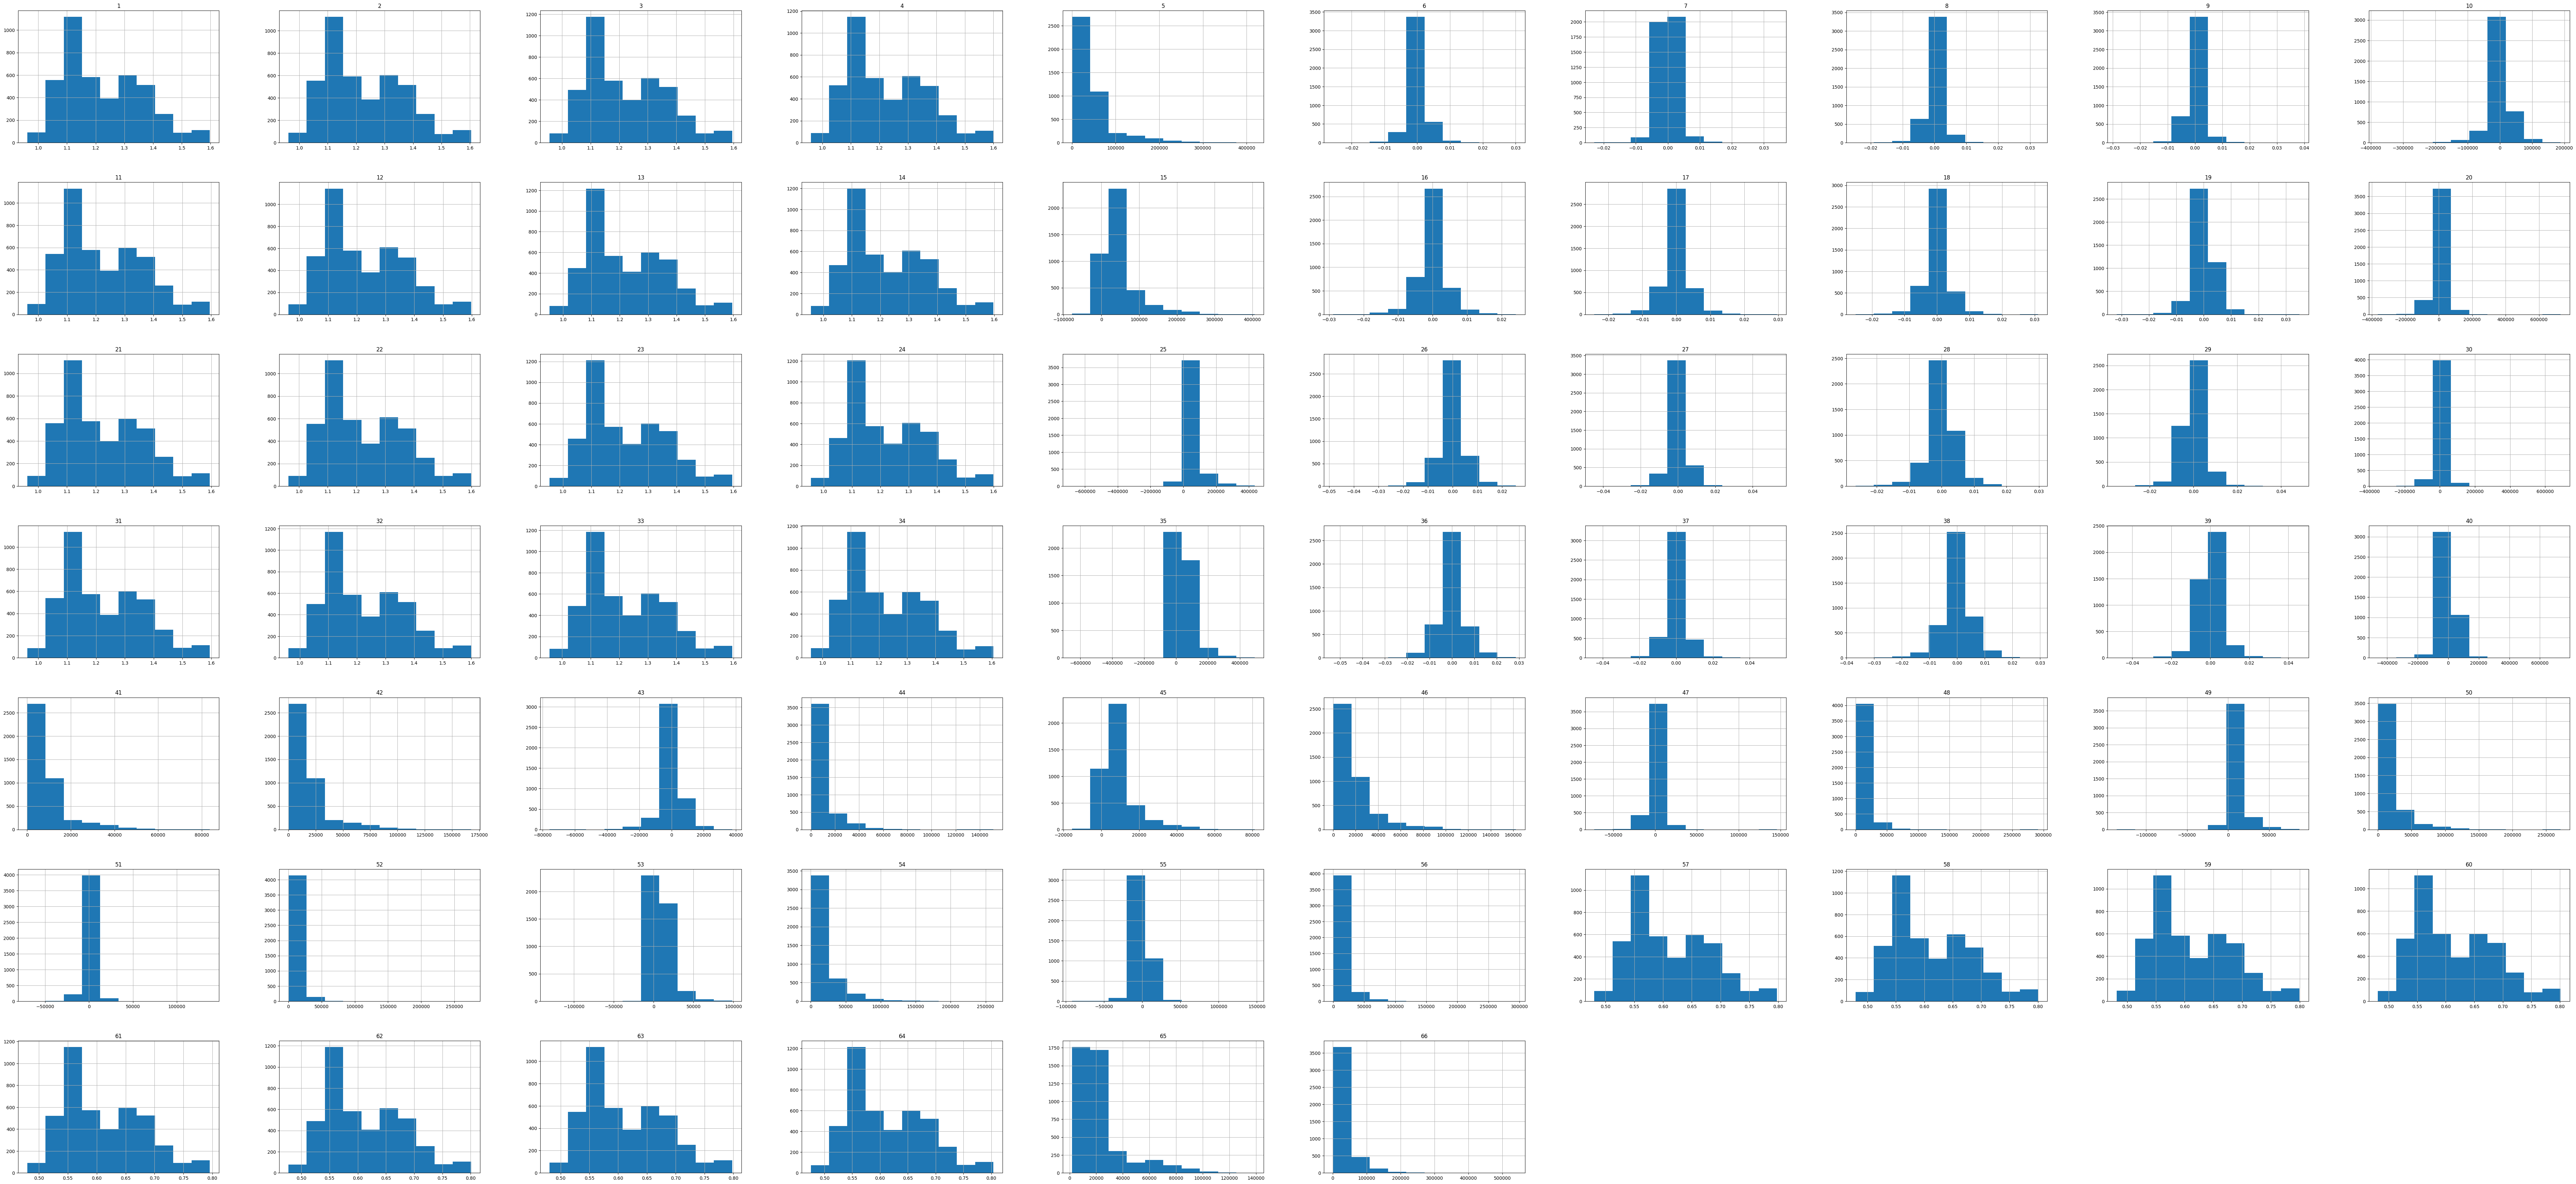

In [30]:
# Cell 4
df2 = pd.DataFrame(dlist, columns=[str(i + 1) for i in range(dlist.shape[1])])
print(df2.head())
df2[list(df2.columns)] = df2[list(df2.columns)].apply(pd.to_numeric)
df2.hist(layout=(15,10), figsize=(100,100))

plt.savefig('foo.png')

In [31]:
# Cell 5
from sklearn.preprocessing import MinMaxScaler
std_scaler = MinMaxScaler()
scaled_df = std_scaler.fit_transform(dlist)

from sklearn.decomposition import PCA

pca = PCA(n_components=3)
dlist = pca.fit_transform(scaled_df)

print(dlist.shape, type(dlist))
print(dlist[0:30, ])

(4307, 3) <class 'numpy.ndarray'>
[[ 1.84636406  0.14575483  0.10563348]
 [ 1.87099336  0.30010584 -0.13495388]
 [ 1.87882799  0.31712203  0.18664047]
 [ 1.89835598  0.30772675 -0.08340327]
 [ 1.91774828  0.31760369  0.16480837]
 [ 1.98149909  0.27974597 -0.00989667]
 [ 1.97350482  0.17805363  0.05097916]
 [ 2.01148182  0.83077558  0.18801692]
 [ 2.09136548  0.82262949  0.55154259]
 [ 2.21653596  0.81837858  0.12729115]
 [ 2.26883338  0.8249431   0.06936935]
 [ 2.286379    0.77638074 -0.06383887]
 [ 2.29731862  0.72207584 -0.12128354]
 [ 2.29813879  0.72939022 -0.02233662]
 [ 2.30783623  0.74149351  0.4442028 ]
 [ 2.3952896   0.75130158  0.18234243]
 [ 2.42102537  0.49123409 -0.14094061]
 [ 2.43063864  1.218995   -0.12830288]
 [ 2.43565259  1.21589862  0.04308265]
 [ 2.48133469  1.21924766  0.61176687]
 [ 2.57125128  1.20042428  0.19091527]
 [ 2.60976158  1.3540915   0.52642244]
 [ 2.72851877  0.5061558  -0.20273176]
 [ 2.69723609  0.494318   -0.30095098]
 [ 2.63222444  0.48816322 -0.3

          1         2         3
0  1.846364  0.145755  0.105633
1  1.870993  0.300106 -0.134954
2  1.878828  0.317122  0.186640
3  1.898356  0.307727 -0.083403
4  1.917748  0.317604  0.164808
[1.03741324 0.31574057 0.17635002]


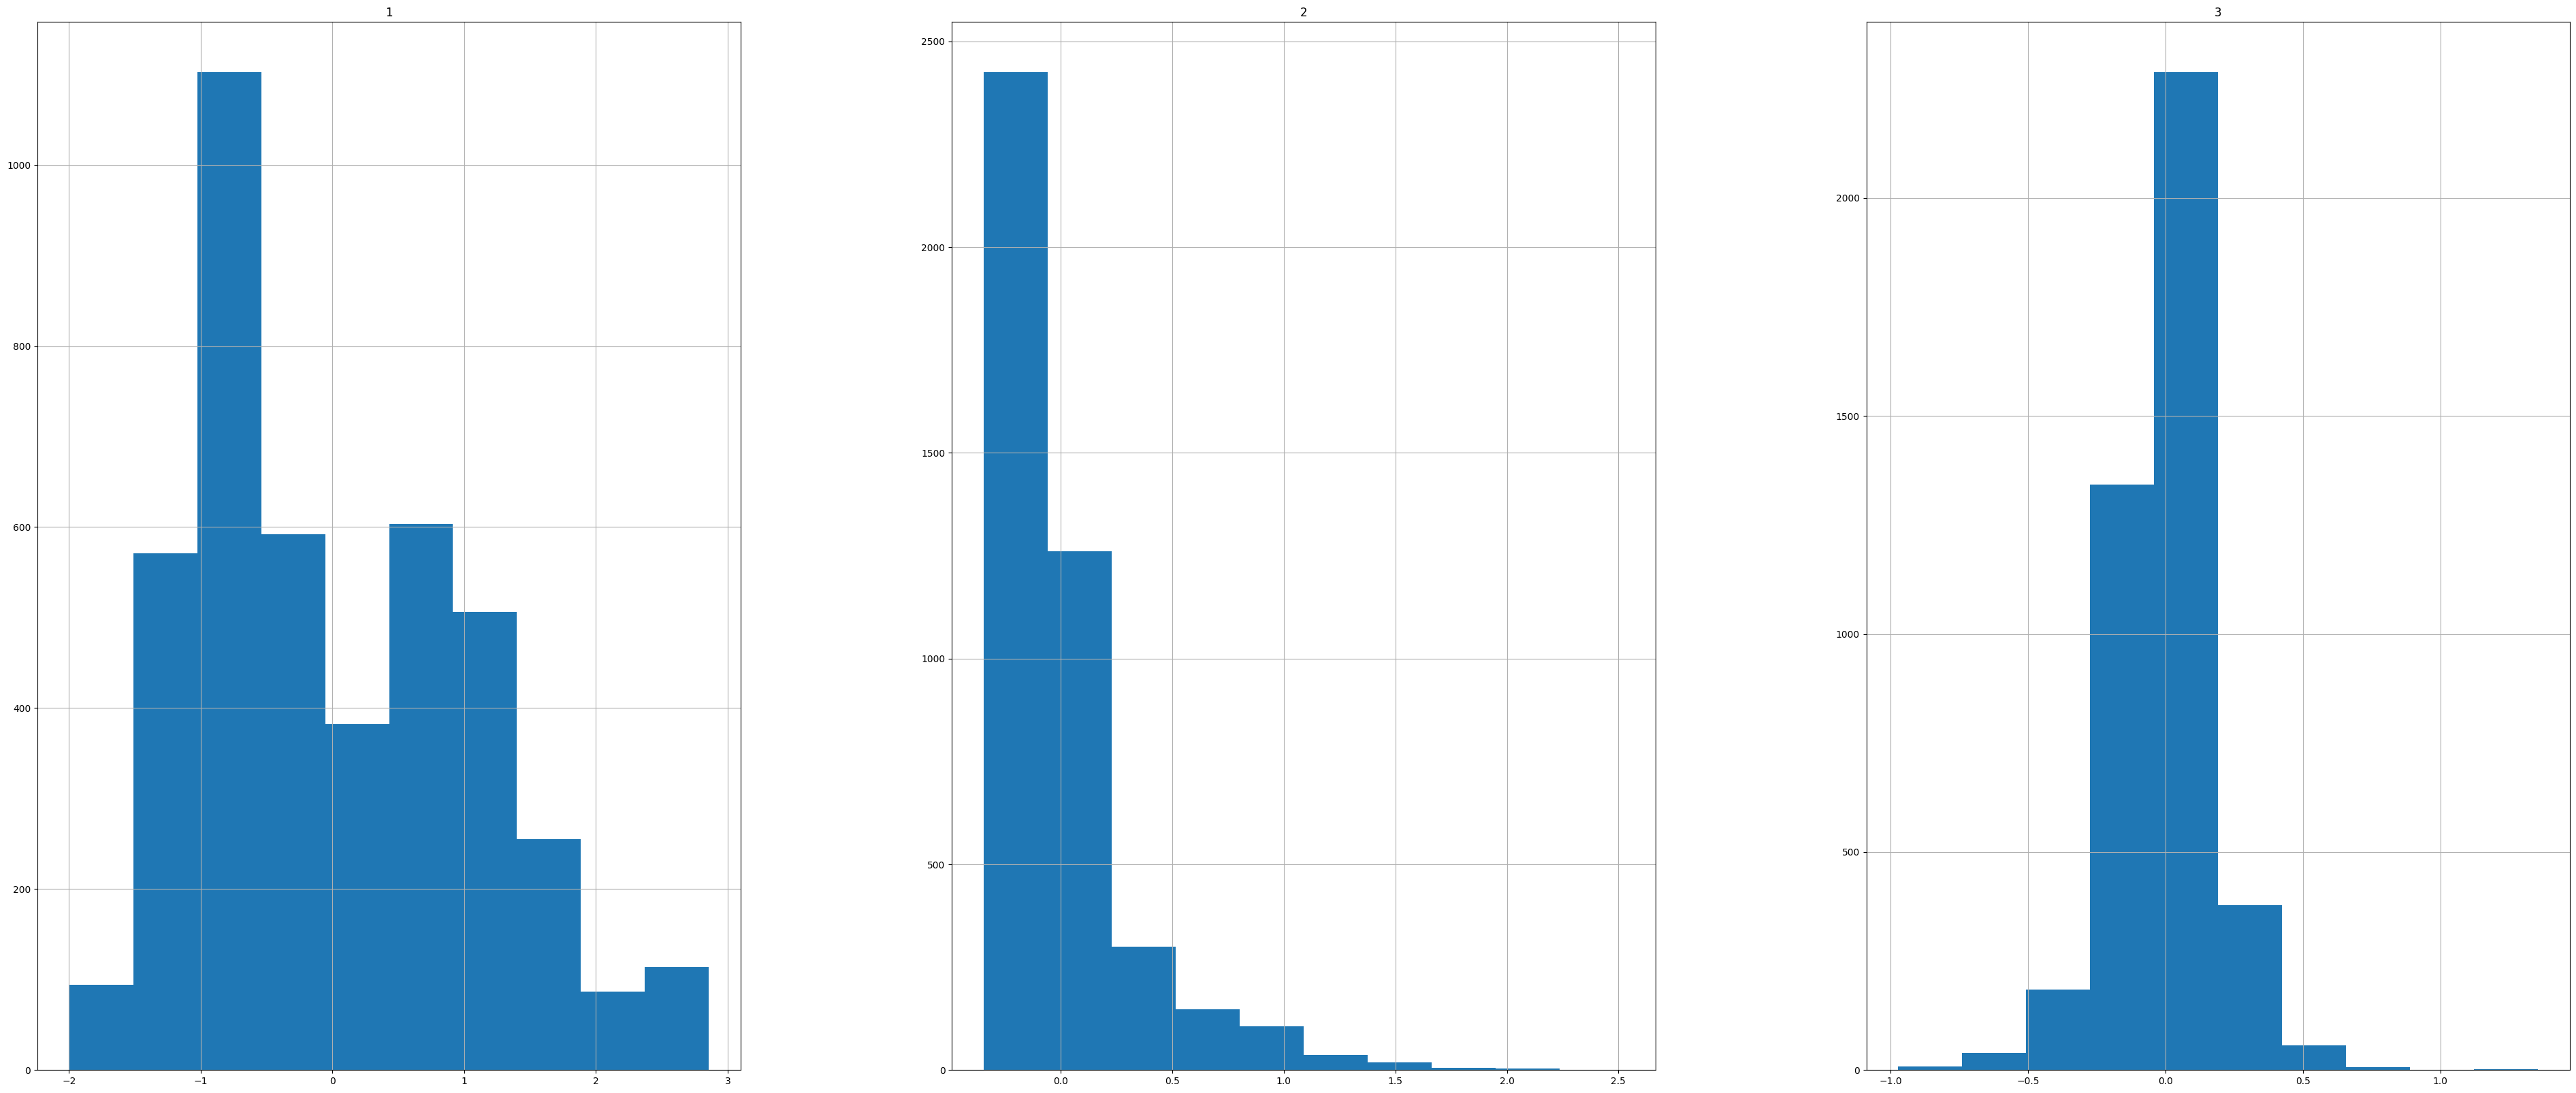

In [32]:
# Cell 6
df2 = pd.DataFrame(dlist, columns=[str(i + 1) for i in range(dlist.shape[1])])
print(df2.head())
df2[list(df2.columns)] = df2[list(df2.columns)].apply(pd.to_numeric)
stds = np.std(dlist, axis=0)
print(stds)
# rank_cols = []
# rank = df2.apply(pd.qcut, axis=0, q=5, labels=False)
# print(rank)

df2.hist(layout=(1, 6), figsize=(100,20))
plt.savefig('foo2.png')

In [33]:
# Cell 7
for i in range(len(dlist)):
    # first, second, third, fourth, fifth = dlist[i][0], dlist[i][1], dlist[i][2], dlist[i][3], dlist[i][4]
    # dlist[i][0] = 0 if first < -1/4 else 1 if -1/4 <= first <= 5/3 else 2
    # dlist[i][1] = 0 if second < 0 else 1
    # dlist[i][2] = 0 if third < 0 else 1
    # dlist[i][3] = 0 if fourth < 0 else 1
    # dlist[i][4] = 0 if fifth < 0 else 1
    first, second, third = dlist[i][0], dlist[i][1], dlist[i][2]
    dlist[i][0] = 0 if first < -1/2 else 1 if -1/2 <= first <= 1/3 else 2
    dlist[i][1] = 0 if second < 0 else 1
    dlist[i][2] = 0

dlist = np.array(dlist, dtype=int)
print(dlist[0:30, ])

[[2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]
 [2 1 0]]


In [34]:
# Cell 8
from collections import defaultdict
z = np.array([0 for ii in range(dlist.shape[0])], dtype=int)
dlist = np.hstack((dlist, z[:, None]))
d = {}
k = 0
index_by_class = defaultdict(list)
for i in range(len(dlist)):
    token = "".join(list(map(str, dlist[i, 0:dlist.shape[1] - 1])))
    if not token in d.keys():
        d[token] = k
        k += 1
    dlist[i][dlist.shape[1] - 1] = d[token]
    index_by_class[d[token]].append(i)

print(dlist[0:30, ])

[[2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]
 [2 1 0 0]]


[[1.40694104e+00 1.41052136e+00 1.40315574e+00 1.40683714e+00
  1.04476482e+05]
 [1.40684165e+00 1.41007630e+00 1.40351712e+00 1.40677758e+00
  9.70911253e+04]
 [1.40678484e+00 1.40959660e+00 1.40346167e+00 1.40641290e+00
  9.54219457e+04]
 [1.40636253e+00 1.40933092e+00 1.40324676e+00 1.40626436e+00
  9.22985741e+04]
 [1.40624015e+00 1.40969881e+00 1.40339251e+00 1.40659981e+00
  9.80717933e+04]
 [1.40660670e+00 1.41015530e+00 1.40325167e+00 1.40682349e+00
  1.04816779e+05]
 [1.40681777e+00 1.41022687e+00 1.40326363e+00 1.40673635e+00
  1.01580823e+05]
 [1.40674167e+00 1.41013192e+00 1.40346612e+00 1.40687756e+00
  9.72455950e+04]]
[[1.36059413e+00 1.36266638e+00 1.35866690e+00 1.36069792e+00
  2.23907459e+04]
 [1.36068421e+00 1.36284550e+00 1.35845169e+00 1.36066544e+00
  2.57380164e+04]
 [1.36065718e+00 1.36281299e+00 1.35826697e+00 1.36044165e+00
  2.75278519e+04]
 [1.36042673e+00 1.36270591e+00 1.35819330e+00 1.36044655e+00
  2.79849664e+04]
 [1.36043724e+00 1.36257880e+00 1.35807

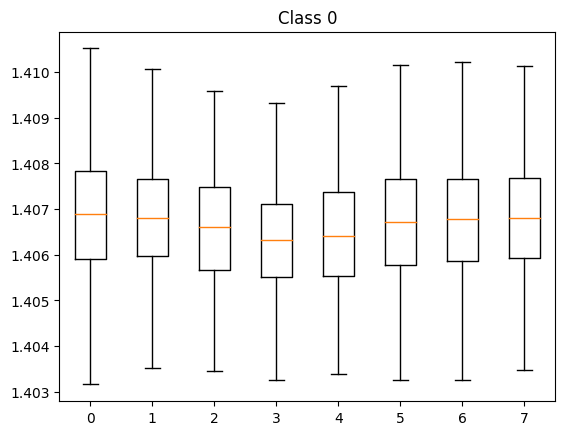

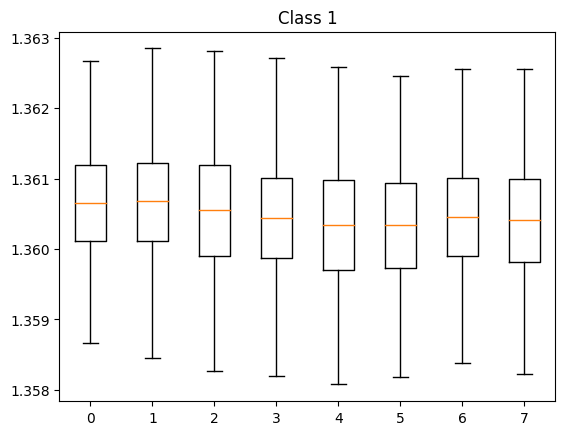

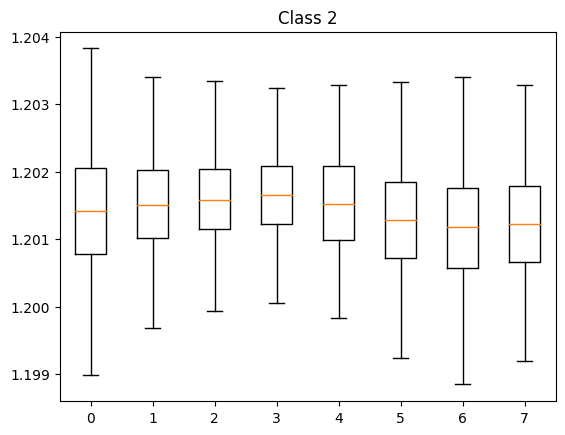

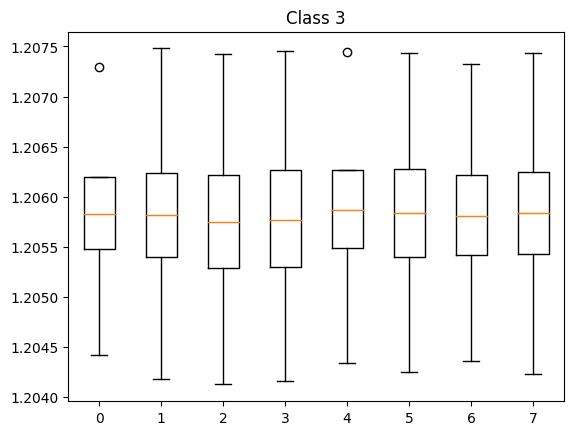

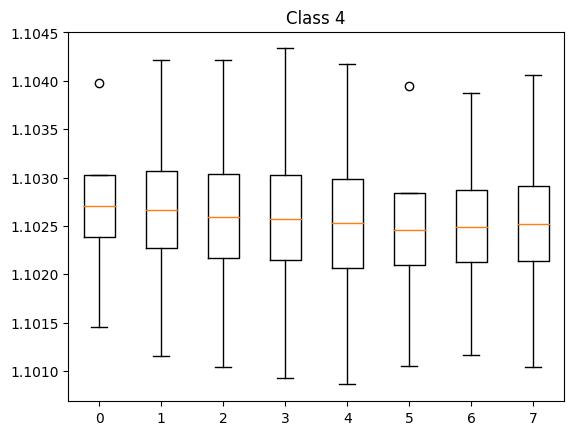

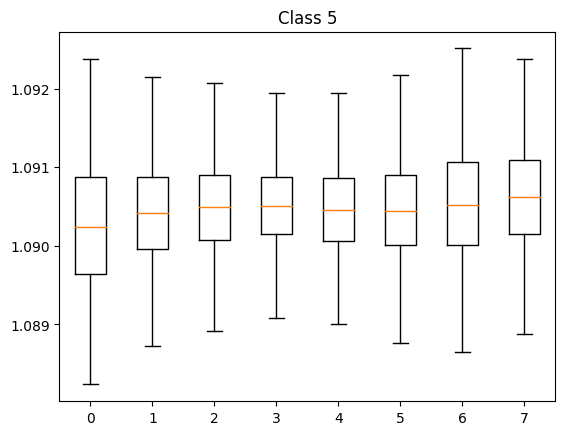

In [56]:
# Cell 8.5
# l = len(list(d.keys()))

# print(d4plotting.shape)

# mean_box = np.zeros((l, d4plotting.shape[1]))
# # print(f"shape: {mean_box.shape}")
# for j in range(l):
#     mean_box[j] = np.mean(d4plotting[index_by_class[j]], axis=0)
# mean_box = mean_box.reshape(l, -1, 5)
# print(mean_box.shape)

for lcount in range(l):
    print(mean_box[lcount])
    my_dict = {str(j): mean_box[lcount][j, :mean_box.shape[2] - 1] for j in range(mean_box.shape[1])}
    fig, ax = plt.subplots()
    ax.boxplot(my_dict.values())
    ax.set_title(f"Class {str(lcount)}")
    ax.set_xticklabels(my_dict.keys())
plt.show()

   1  2  3  4
0  2  1  0  0
1  2  1  0  0
2  2  1  0  0
3  2  1  0  0
4  2  1  0  0
[0.89484347 0.46891233 0.         1.71083283]


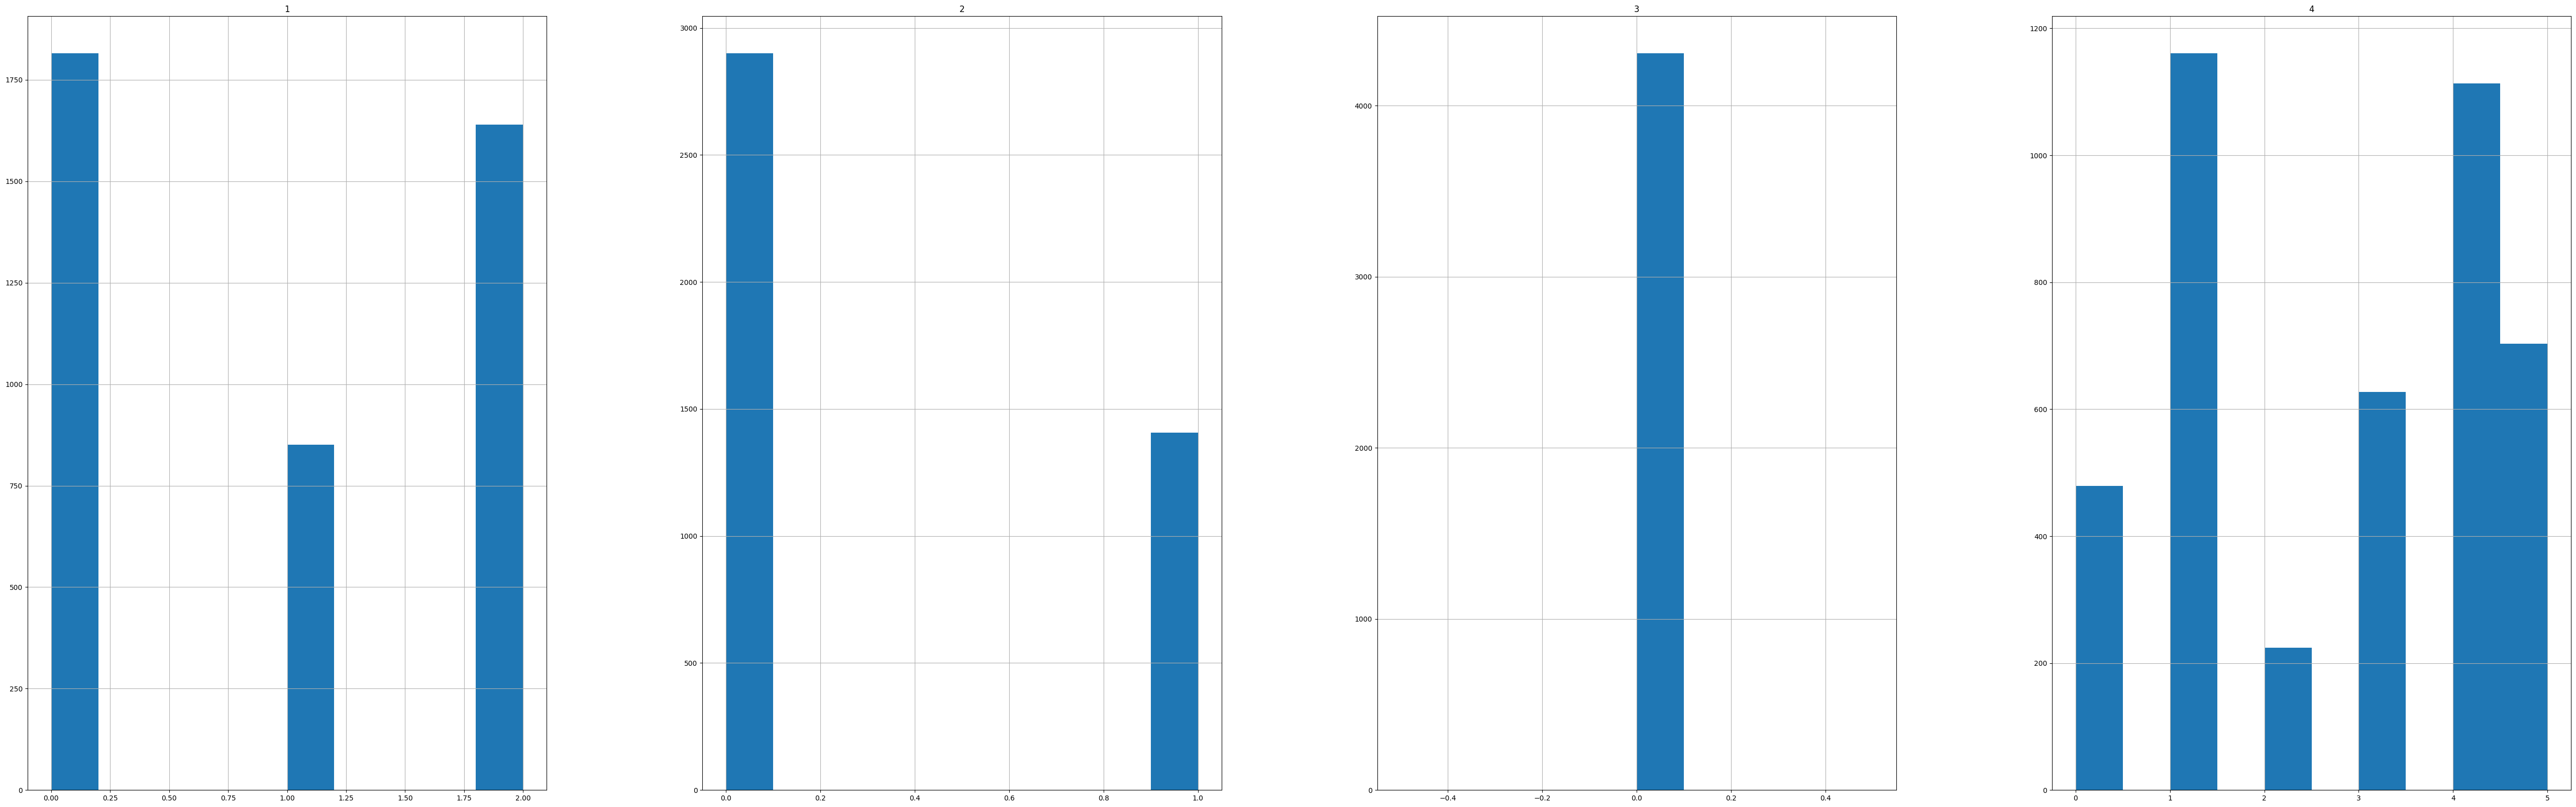

In [38]:
# Cell 9
df2 = pd.DataFrame(dlist, columns=[str(i + 1) for i in range(dlist.shape[1])])
print(df2.head())
df2[list(df2.columns)] = df2[list(df2.columns)].apply(pd.to_numeric)
stds = np.std(dlist, axis=0)
print(stds)
# rank_cols = []
# rank = df2.apply(pd.qcut, axis=0, q=5, labels=False)
# print(rank)

df2.hist(layout=(1, 6), figsize=(100,20))
plt.savefig('foo3.png')

In [39]:
# Cell 10
w = 5  # window size (number of tokens in a sample)

def generage_samples(labels, w):
  n = len(labels)
  X, y = [], []
  i = 0
  while i + w + 1 < n:
    X.append(labels[i : i+w])
    y.append(labels[i+w])
    i += (w+1)
  return pd.DataFrame({'X':X, 'y':y})

samples = generage_samples(dlist[:, dlist.shape[1] - 1], w)
samples

,X,y
0,"[0, 0, 0, 0, 0]",0
1,"[0, 0, 0, 0, 0]",0
2,"[0, 0, 0, 0, 0]",0
3,"[0, 0, 0, 0, 0]",0
4,"[0, 0, 0, 0, 0]",0
...,...,...
712,"[4, 4, 4, 5, 4]",4
713,"[4, 4, 4, 4, 4]",4
714,"[5, 5, 5, 4, 5]",5
715,"[5, 5, 5, 4, 5]",5


In [40]:
# Cell 11
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(samples.X, samples.y, test_size=0.2, random_state=42)
train_data = pd.concat((X_train, y_train), axis=1)
X_train, X_val, y_train, y_val = train_test_split(train_data.X, train_data.y, test_size=0.1, random_state=42)

print(f'X_train:{X_train.shape}  y_train:{y_train.shape}')
print(f'X_test :{X_test.shape}  y_test :{y_test.shape}')
print(f'X_val  :{X_val.shape}   y_val  :{y_val.shape}')

X_train:(515,)  y_train:(515,)
X_test :(144,)  y_test :(144,)
X_val  :(58,)   y_val  :(58,)


In [41]:
# Cell 12
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [42]:
# Cell 13
class ChartDataset(Dataset):
    def __init__(self, x, y):
      self.x = x
      self.y = y

    def __getitem__(self, idx):
      input = {'input_ids': torch.tensor(self.x[idx]).to(device), 'attention_mask': torch.ones(len(self.x[idx])).to(device)}
      labels = torch.ones(len(self.x[idx]), dtype=torch.long) * -100
      labels[-1] = self.y[idx]
      # labels[-3:-1] = torch.tensor(self.x[idx][-2:])
      labels = labels.to(device)
      return input, labels

    def __len__(self):
      return len(self.y)

train_dataset = ChartDataset(X_train.to_numpy(), y_train.to_numpy())
val_dataset = ChartDataset(X_val.to_numpy(), y_val.to_numpy())
test_dataset = ChartDataset(X_test.to_numpy(), y_test.to_numpy())

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [43]:
# Cell 14
def train_one_epoch(model, dataloader, optimizer):
  model.train()
  accu_loss = 0
  for x, y in dataloader:
    optimizer.zero_grad()
    loss = model(input_ids=x['input_ids'], attention_mask=x['attention_mask'], labels=y).loss
    accu_loss += loss.item()
    loss.backward()
    optimizer.step()
  overall_loss = accu_loss / len(dataloader)
  return overall_loss

def test_one_epoch(model, dataloader):
  model.eval()
  with torch.no_grad():
    accu_loss = 0
    for x, y in dataloader:
      loss = model(input_ids=x['input_ids'], attention_mask=x['attention_mask'], labels=y).loss
      accu_loss += loss.item()
    overall_loss = accu_loss / len(dataloader)
  return overall_loss

In [44]:
# Cell 15
from transformers import GPT2LMHeadModel, GPT2Tokenizer, GPT2Config

configuration = GPT2Config(vocab_size=len(list(d.keys())), n_positions=w+1)
gpt_pretrained = GPT2LMHeadModel.from_pretrained('gpt2')
gpt = GPT2LMHeadModel(configuration)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [45]:
# Cell 16
state = gpt_pretrained.state_dict()
del state['transformer.wte.weight']
del state['transformer.wpe.weight']
del state['lm_head.weight']
gpt.load_state_dict(state, strict=False)

_IncompatibleKeys(missing_keys=['transformer.wte.weight', 'transformer.wpe.weight', 'lm_head.weight'], unexpected_keys=[])

In [46]:
# Cell 17
for i, j in zip(gpt.parameters(), gpt_pretrained.parameters()):
  if i.shape != j.shape:
    continue
  i.requires_grad = False

In [47]:
# Cell 18
lr = 1e-4
optimizer = Adam(gpt.parameters(), lr=lr)
gpt = gpt.to(device)
epoch = 30

In [48]:
# Cell 19
import gc
train_losses = []
val_losses = []
for i in range(epoch):
  gc.collect()
  train_loss = train_one_epoch(gpt, train_dataloader, optimizer)
  val_loss = test_one_epoch(gpt, val_dataloader)
  train_losses.append(train_loss)
  val_losses.append(val_loss)
  print(f'Epoch {i+1}: Train Loss = {train_loss:0.3}, Val Loss = {val_loss:0.3}')

Epoch 1: Train Loss = 2.48, Val Loss = 1.65
Epoch 2: Train Loss = 2.22, Val Loss = 1.78
Epoch 3: Train Loss = 2.08, Val Loss = 1.59
Epoch 4: Train Loss = 1.9, Val Loss = 1.57
Epoch 5: Train Loss = 1.81, Val Loss = 1.55
Epoch 6: Train Loss = 1.71, Val Loss = 1.61
Epoch 7: Train Loss = 1.6, Val Loss = 1.45
Epoch 8: Train Loss = 1.55, Val Loss = 1.42
Epoch 9: Train Loss = 1.58, Val Loss = 1.51
Epoch 10: Train Loss = 1.5, Val Loss = 1.49
Epoch 11: Train Loss = 1.5, Val Loss = 1.41
Epoch 12: Train Loss = 1.46, Val Loss = 1.44
Epoch 13: Train Loss = 1.5, Val Loss = 1.4
Epoch 14: Train Loss = 1.47, Val Loss = 1.42
Epoch 15: Train Loss = 1.54, Val Loss = 1.39
Epoch 16: Train Loss = 1.46, Val Loss = 1.32
Epoch 17: Train Loss = 1.33, Val Loss = 1.19
Epoch 18: Train Loss = 1.34, Val Loss = 1.18
Epoch 19: Train Loss = 1.35, Val Loss = 1.17
Epoch 20: Train Loss = 1.34, Val Loss = 1.11
Epoch 21: Train Loss = 1.28, Val Loss = 1.17
Epoch 22: Train Loss = 1.23, Val Loss = 1.18
Epoch 23: Train Loss = 1.

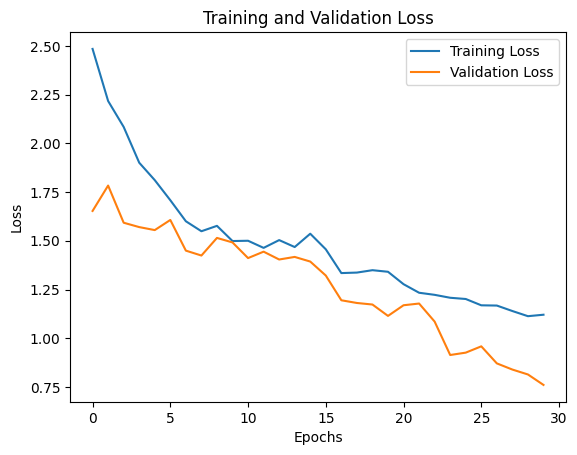

In [49]:
# Cell 20
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(loc='best')
plt.show()

    0   1  2   3   4   5
0  10   9  0   1   0   0
1   0  42  0   0   0   0
2   0   0  1   2   0   1
3   0   0  3  11   1   2
4   0   0  1   0  31   5
5   0   0  0   0  10  14


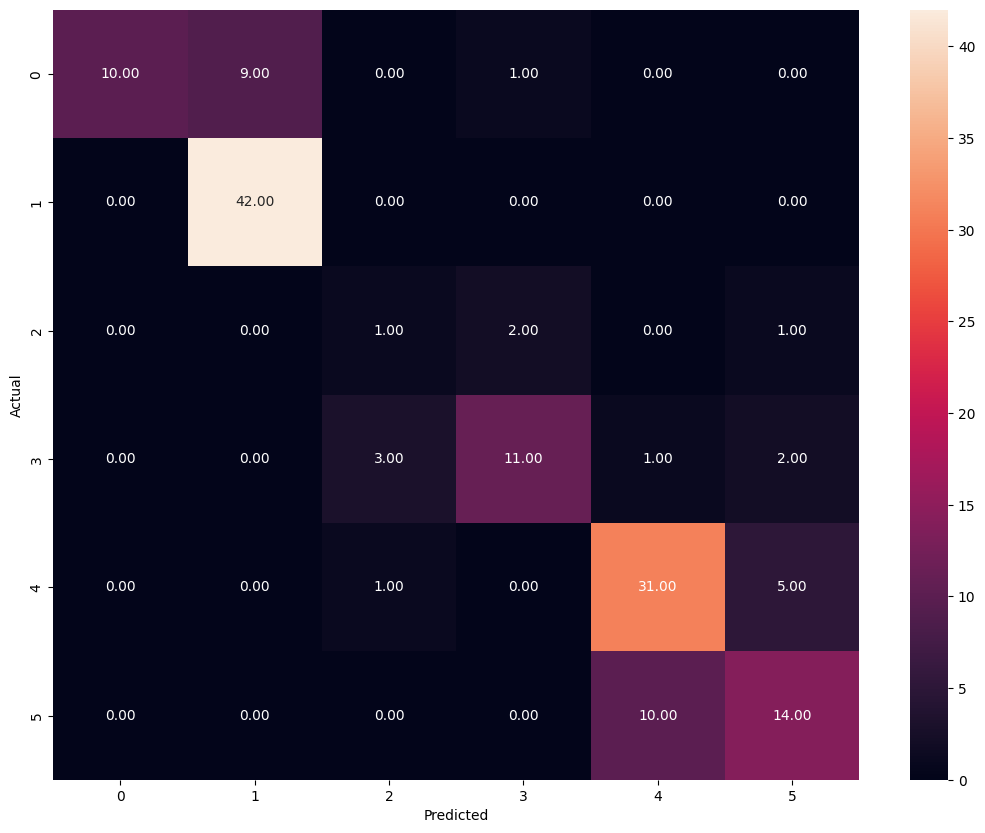

          0         1         2         3         4         5
0  1.000000  0.981404  0.993841  0.972641  0.915605  0.996003
1  0.981404  1.000000  0.961653  0.998717  0.974464  0.964532
2  0.993841  0.961653  1.000000  0.949016  0.883595  0.998463
3  0.972641  0.998717  0.949016  1.000000  0.982543  0.952996
4  0.915605  0.974464  0.883595  0.982543  1.000000  0.885387
5  0.996003  0.964532  0.998463  0.952996  0.885387  1.000000


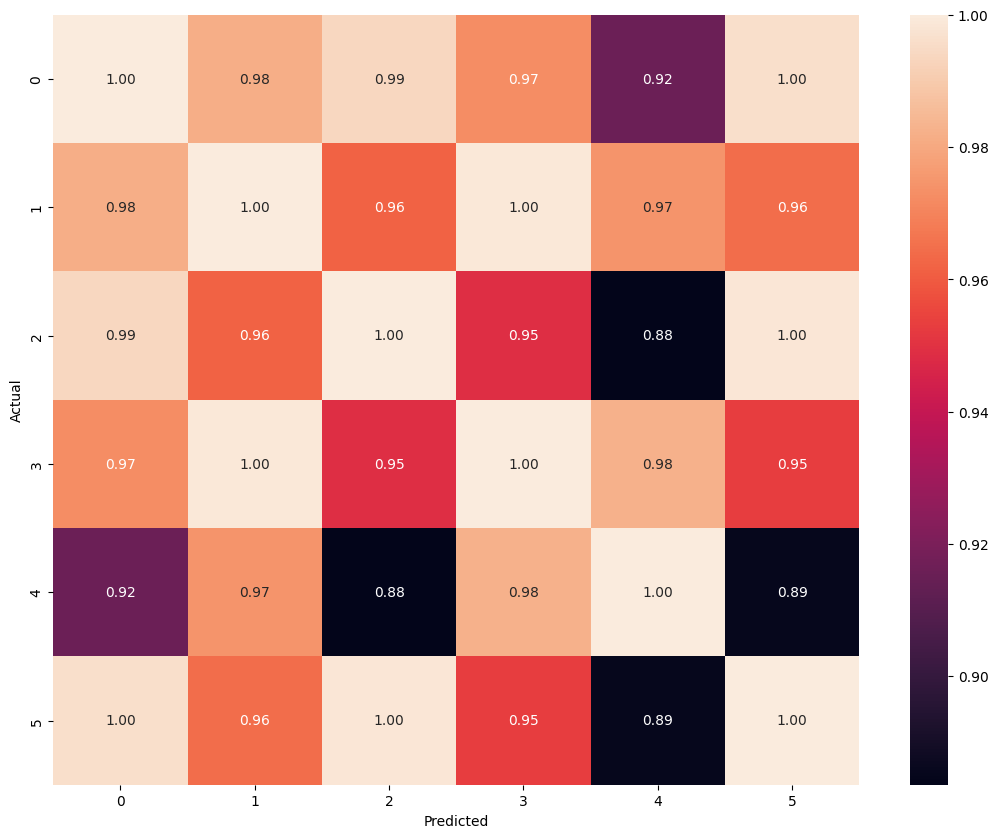

In [50]:
# Cell 21
import seaborn as sns
from numpy import dot
from numpy.linalg import norm

def cos_sim(a, b):
    return dot(a, b)/(norm(a)*norm(b))


ypred = []
ytrue = []
for x, y in test_dataloader:
    logit = gpt(input_ids=x['input_ids'], attention_mask=x['attention_mask'], labels=y).logits
    e_l1 = logit.cpu().detach().numpy()
    e_l1 = e_l1[0]
    label_pred = e_l1[e_l1.shape[0] - 1].argmax(axis=0)
    y_np = y.cpu().detach().numpy()
    label_true = y_np[0][len(y_np[0]) - 1]
    ypred.append(label_pred)
    ytrue.append(label_true)


from sklearn.metrics import confusion_matrix

cm = confusion_matrix(ytrue, ypred)
target_names = [i for i in "012345"]
df_cm = pd.DataFrame(cm, index = target_names,
                     columns = target_names)
print(df_cm)
# df_cm = df_cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(13,10))
sns.heatmap(df_cm, annot=True, fmt='.2f', xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show(block=False)

l = len(list(d.keys()))
mean_arr = np.zeros((l, dlist_copy.shape[1]))
# print(f"shape: {mean_arr.shape}")
for j in range(l):
    mean_arr[j] = np.mean(dlist_copy[index_by_class[j]], axis=0)
    # print(mean_arr[j])
true_cm = np.zeros((l, l))
for j in range(l):
    for jj in range(j + 1):
        true_cm[j][jj] = cos_sim(mean_arr[j], mean_arr[jj])
        true_cm[jj][j] = true_cm[j][jj]
df_cm2 = pd.DataFrame(true_cm, index = [i for i in "012345"],
                     columns = [i for i in "012345"])
print(df_cm2)
fig, ax = plt.subplots(figsize=(13,10))
sns.heatmap(df_cm2, annot=True, fmt='.2f', xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show(block=False)